<a href="https://colab.research.google.com/github/Mohamedboukerche22/simple-llm/blob/main/still_in_scratrch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [154]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler ,PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

In [155]:
f_pipline = Pipeline([
    ('scaler',StandardScaler()),
    ('poly',PolynomialFeatures(degree=2))
])

In [156]:
# clean data
# remove all houses that cost more than 5 to make our model better predict
#df = fetch_california_housing(as_frame=True).frame
#df_cleaned = df[df['MedHouseVal'] < 5.0]
#X = df_cleaned.drop(columns=['MedHouseVal'])
#y = df_cleaned['MedHouseVal']

## UPDATE : it make it worst :<

X,y = fetch_california_housing(return_X_y=True)
# split data
X_train ,X_test, y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=24)

In [157]:
model = RandomForestRegressor()
wrapped_model  = TransformedTargetRegressor(regressor=model,
                                            func=np.log1p,
                                            inverse_func=np.expm1
                                            )

In [158]:
full_pipeline = Pipeline([
    ('preprocessing', f_pipline),
    ('regressor', wrapped_model)
])

In [159]:
#pred = model.predict(X_test)
full_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('scaler', StandardScaler()),
                                 ('poly', PolynomialFeatures())])),
                ('regressor',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor()))])

In [160]:
pred = full_pipeline.predict(X_test)

In [161]:
print(r2_score(y_test,pred))

0.8034360773322339


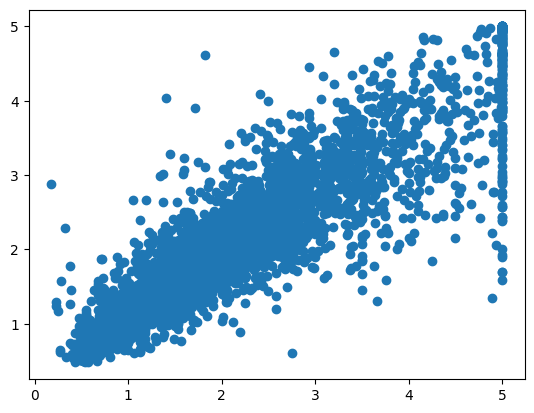

In [162]:
plt.scatter(y_test,pred)
